In [2]:
# Cell 1: Imports and basic configuration

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    BatchNormalization,
    Dropout,
    Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Dataset paths
TRAIN_PATH = "combined_dataset/train"
VALID_PATH = "combined_dataset/valid"
TEST_PATH = "combined_dataset/test"

# Number of classes
NUM_CLASSES = 3

# Class names in the required order
CLASS_NAMES = ["Normal", "Pneumonia", "Tuberculosis"]

print("TensorFlow version:", tf.__version__)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

print("\nDataset paths:")
print("Train:", TRAIN_PATH)
print("Validation:", VALID_PATH)
print("Test:", TEST_PATH)

TensorFlow version: 2.21.0
Image size: (224, 224)
Batch size: 32
Number of classes: 3
Class names: ['Normal', 'Pneumonia', 'Tuberculosis']

Dataset paths:
Train: combined_dataset/train
Validation: combined_dataset/valid
Test: combined_dataset/test


In [6]:
# Cell 2: Verify dataset structure and image counts

from pathlib import Path

# Check that dataset directories exist
for path_name, path_value in [
    ("Training", TRAIN_PATH),
    ("Validation", VALID_PATH),
    ("Test", TEST_PATH)
]:
    print(f"{path_name} path exists:", os.path.exists(path_value), "->", path_value)

print("\n" + "=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

# Verify class folders and count images
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

for split_name, split_path in [
    ("Train", TRAIN_PATH),
    ("Validation", VALID_PATH),
    ("Test", TEST_PATH)
]:
    print(f"\n{split_name}:")
    
    total_count = 0
    
    for class_name in CLASS_NAMES:
        class_path = Path(split_path) / class_name
        
        if not class_path.exists():
            print(f"  {class_name}: FOLDER NOT FOUND")
            continue
        
        image_count = sum(
            1 for file in class_path.rglob("*")
            if file.is_file() and file.suffix.lower() in valid_extensions
        )
        
        total_count += image_count
        print(f"  {class_name}: {image_count}")
    
    print(f"  Total: {total_count}")

Training path exists: True -> combined_dataset/train
Validation path exists: True -> combined_dataset/valid
Test path exists: True -> combined_dataset/test

DATASET STRUCTURE

Train:
  Normal: 1491
  Pneumonia: 2973
  Tuberculosis: 1166
  Total: 5630

Validation:
  Normal: 805
  Pneumonia: 861
  Tuberculosis: 250
  Total: 1916

Test:
  Normal: 241
  Pneumonia: 411
  Tuberculosis: 250
  Total: 902


In [7]:
# Cell 3: Create training, validation, and test generators

# Training data generator
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.10,
    brightness_range=[0.9, 1.1],
    horizontal_flip=False,
    fill_mode="nearest"
)

# Validation and test data generator
valid_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

# Validation generator
validation_generator = valid_test_datagen.flow_from_directory(
    VALID_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Test generator
test_generator = valid_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\n" + "=" * 60)
print("GENERATOR INFORMATION")
print("=" * 60)

print("Training samples   :", train_generator.samples)
print("Validation samples :", validation_generator.samples)
print("Test samples       :", test_generator.samples)

print("\nClass indices:")
print(train_generator.class_indices)

print("\nGenerator classes:")
print("Normal = 0")
print("Pneumonia = 1")
print("Tuberculosis = 2")

Found 5630 images belonging to 3 classes.
Found 1916 images belonging to 3 classes.
Found 902 images belonging to 3 classes.

GENERATOR INFORMATION
Training samples   : 5630
Validation samples : 1916
Test samples       : 902

Class indices:
{'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}

Generator classes:
Normal = 0
Pneumonia = 1
Tuberculosis = 2


In [8]:
# Cell 4: Calculate class weights from the training set

train_labels = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(
    enumerate(class_weights_array)
)

print("=" * 60)
print("CLASS WEIGHTS")
print("=" * 60)

for class_index, weight in class_weights.items():
    print(f"{CLASS_NAMES[class_index]} (class {class_index}): {weight:.6f}")

print("\nTraining class distribution:")

unique_classes, class_counts = np.unique(train_labels, return_counts=True)

for class_index, count in zip(unique_classes, class_counts):
    print(f"{CLASS_NAMES[class_index]}: {count}")

CLASS WEIGHTS
Normal (class 0): 1.258663
Pneumonia (class 1): 0.631237
Tuberculosis (class 2): 1.609491

Training class distribution:
Normal: 1491
Pneumonia: 2973
Tuberculosis: 1166


In [9]:
# Cell 5: Build MobileNetV2 baseline model

# Load MobileNetV2 with ImageNet pretrained weights
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained backbone
base_model.trainable = False

# Build classification head
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation="relu")(x)

x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

# Create final model
model = Model(
    inputs=base_model.input,
    outputs=outputs,
    name="MobileNetV2_Baseline"
)

print("=" * 60)
print("MOBILENETV2 MODEL CREATED")
print("=" * 60)

print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Backbone trainable:", base_model.trainable)

MOBILENETV2 MODEL CREATED
Model name: MobileNetV2_Baseline
Input shape: (None, 224, 224, 3)
Output shape: (None, 3)
Backbone trainable: False


In [10]:
# Cell 6: Verify MobileNetV2 architecture and parameter counts

print("=" * 80)
print("MOBILENETV2 BASELINE ARCHITECTURE")
print("=" * 80)

model.summary()

# Calculate parameter counts
total_params = model.count_params()

trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in model.trainable_variables
])

non_trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in model.non_trainable_variables
])

print("\n" + "=" * 80)
print("PARAMETER COUNTS")
print("=" * 80)

print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Non-trainable params  : {non_trainable_params:,}")

print("\nTrainable + Non-trainable:",
      f"{trainable_params + non_trainable_params:,}")

MOBILENETV2 BASELINE ARCHITECTURE


Model: "MobileNetV2_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,592,835 (9.89 MB)

 Trainable params: 331,779 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)


PARAMETER COUNTS
Total parameters      : 2,592,835
Trainable parameters  : 331,779
Non-trainable params  : 2,261,060

Trainable + Non-trainable: 2,592,839


In [11]:
# Cell 7: Compile MobileNetV2 baseline model

optimizer = Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 60)
print("MOBILENETV2 MODEL COMPILED")
print("=" * 60)

print("Optimizer        : Adam")
print("Learning rate    : 1e-4")
print("Loss             : categorical_crossentropy")
print("Metric           : accuracy")
print("Backbone frozen  :", not base_model.trainable)

MOBILENETV2 MODEL COMPILED
Optimizer        : Adam
Learning rate    : 1e-4
Loss             : categorical_crossentropy
Metric           : accuracy
Backbone frozen  : True


In [12]:
# Cell 8: Create training callbacks

# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Save only the model with the best validation loss
model_checkpoint = ModelCheckpoint(
    "MobileNetV2_best.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr,
    model_checkpoint
]

print("=" * 60)
print("TRAINING CALLBACKS CREATED")
print("=" * 60)

print("EarlyStopping:")
print("  Monitor              : val_loss")
print("  Patience             : 5")
print("  Restore best weights : True")

print("\nReduceLROnPlateau:")
print("  Monitor   : val_loss")
print("  Factor    : 0.2")
print("  Patience  : 2")
print("  Min LR    : 1e-7")

print("\nModelCheckpoint:")
print("  File       : MobileNetV2_best.keras")
print("  Monitor    : val_loss")
print("  Save best  : True")

TRAINING CALLBACKS CREATED
EarlyStopping:
  Monitor              : val_loss
  Patience             : 5
  Restore best weights : True

ReduceLROnPlateau:
  Monitor   : val_loss
  Factor    : 0.2
  Patience  : 2
  Min LR    : 1e-7

ModelCheckpoint:
  File       : MobileNetV2_best.keras
  Monitor    : val_loss
  Save best  : True


In [ ]:
# Cell 9: Train MobileNetV2 baseline model

print("=" * 60)
print("STARTING MOBILENETV2 TRAINING")
print("=" * 60)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("MOBILENETV2 TRAINING COMPLETED")
print("=" * 60)

print("Epochs actually completed:", len(history.history["loss"]))

STARTING MOBILENETV2 TRAINING
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7442 - loss: 0.6315
Epoch 1: val_loss improved from None to 0.24567, saving model to MobileNetV2_best.keras

Epoch 1: finished saving model to MobileNetV2_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.7442 - loss: 0.6315 - val_accuracy: 0.9165 - val_loss: 0.2457 - learning_rate: 1.0000e-04
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8702 - loss: 0.3377
Epoch 2: val_loss improved from 0.24567 to 0.21705, saving model to MobileNetV2_best.keras

Epoch 2: finished saving model to MobileNetV2_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.8702 - loss: 0.3377 - val_accuracy: 0.9149 - val_loss: 0.2170 - learning_rate: 1.0000e-04
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8876 - loss: 0.2772
Epoch 3: val_loss improved from 0.21705 to 0.20369, saving model to MobileNetV2_best.keras

Epoch 3: finished saving model to Mo

In [3]:
# Cell 10: Resume MobileNetV2 training from the best checkpoint

print("=" * 60)
print("LOADING BEST MOBILE NETV2 CHECKPOINT")
print("=" * 60)

# Load the best checkpoint saved during the previous training
model = tf.keras.models.load_model(
    "MobileNetV2_best.keras"
)

print("Checkpoint loaded successfully.")
print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

# Check that the optimizer was restored
print("\nOptimizer:", type(model.optimizer).__name__)
print("Learning rate:",
      float(tf.keras.backend.get_value(model.optimizer.learning_rate)))

print("\nStarting from Epoch 10...")
print("Previous completed epoch: 9")
print("Remaining maximum epochs: 10")

LOADING BEST MOBILE NETV2 CHECKPOINT
Checkpoint loaded successfully.
Model name: MobileNetV2_Baseline
Input shape: (None, 224, 224, 3)
Output shape: (None, 3)

Optimizer: Adam
Learning rate: 9.999999747378752e-05

Starting from Epoch 10...
Previous completed epoch: 9
Remaining maximum epochs: 10


In [4]:
# Cell 11: Resume MobileNetV2 training from completed Epoch 9

BEST_VAL_LOSS = 0.14961

# Recreate callbacks for the resumed training
early_stopping_resume = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    baseline=BEST_VAL_LOSS,
    verbose=1
)

reduce_lr_resume = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint_resume = ModelCheckpoint(
    "MobileNetV2_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    initial_value_threshold=BEST_VAL_LOSS,
    verbose=1
)

resume_callbacks = [
    early_stopping_resume,
    reduce_lr_resume,
    model_checkpoint_resume
]

print("=" * 60)
print("RESUMING MOBILENETV2 TRAINING")
print("=" * 60)

print("Previous completed epoch : 9")
print("Starting epoch           : 10")
print("Maximum epoch            : 20")
print("Previous best val_loss   :", BEST_VAL_LOSS)
print("Current learning rate    :",
      float(tf.keras.backend.get_value(model.optimizer.learning_rate)))

print("\nStarting training...")

RESUMING MOBILENETV2 TRAINING
Previous completed epoch : 9
Starting epoch           : 10
Maximum epoch            : 20
Previous best val_loss   : 0.14961
Current learning rate    : 9.999999747378752e-05

Starting training...


In [13]:
# Cell 12: Resume MobileNetV2 training

print("=" * 60)
print("STARTING RESUMED MOBILENETV2 TRAINING")
print("=" * 60)

history_resume = model.fit(
    train_generator,
    initial_epoch=9,
    epochs=20,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=resume_callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("RESUMED TRAINING COMPLETED")
print("=" * 60)

print("Additional epochs completed:",
      len(history_resume.history["loss"]))

STARTING RESUMED MOBILENETV2 TRAINING
Epoch 10/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.7616 - loss: 0.5750
Epoch 10: val_loss did not improve from 0.14961
176/176 ━━━━━━━━━━━━━━━━━━━━ 169s 928ms/step - accuracy: 0.7616 - loss: 0.5750 - val_accuracy: 0.9097 - val_loss: 0.2614 - learning_rate: 1.0000e-04
Epoch 11/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.8618 - loss: 0.3440
Epoch 11: val_loss did not improve from 0.14961
176/176 ━━━━━━━━━━━━━━━━━━━━ 146s 831ms/step - accuracy: 0.8618 - loss: 0.3440 - val_accuracy: 0.9269 - val_loss: 0.1980 - learning_rate: 1.0000e-04
Epoch 12/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.8902 - loss: 0.2765
Epoch 12: val_loss did not improve from 0.14961
176/176 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.8902 - loss: 0.2765 - val_accuracy: 0.9301 - val_loss: 0.1983 - learning_rate: 1.0000e-04
Epoch 13/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8988 - loss: 0.2558
Epoch 13: val_loss di

In [14]:
# Cell 13: Load the globally best MobileNetV2 checkpoint
# and save it as the final model

print("=" * 60)
print("LOADING BEST MOBILENETV2 MODEL")
print("=" * 60)

best_model = tf.keras.models.load_model(
    "MobileNetV2_best.keras"
)

print("Best model loaded successfully.")
print("Model name:", best_model.name)
print("Input shape:", best_model.input_shape)
print("Output shape:", best_model.output_shape)

# Save the best model as the final MobileNetV2 model
best_model.save("MobileNetV2_final.keras")

print("\n" + "=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)

print("Best model file  : MobileNetV2_best.keras")
print("Final model file : MobileNetV2_final.keras")
print("Best validation loss : 0.14961")
print("Best validation accuracy : 0.9405")

LOADING BEST MOBILENETV2 MODEL
Best model loaded successfully.
Model name: MobileNetV2_Baseline
Input shape: (None, 224, 224, 3)
Output shape: (None, 3)

FINAL MODEL SAVED
Best model file  : MobileNetV2_best.keras
Final model file : MobileNetV2_final.keras
Best validation loss : 0.14961
Best validation accuracy : 0.9405


In [15]:
# Cell 14: Evaluate MobileNetV2 on the 902-image test set

print("=" * 60)
print("MOBILENETV2 TEST SET EVALUATION")
print("=" * 60)

# Make sure the test generator starts from the first image
test_generator.reset()

test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print("\n" + "=" * 60)
print("MOBILENETV2 TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.6f}")
print(f"Test Accuracy : {test_accuracy:.6f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print("\nTest images evaluated:", test_generator.samples)

MOBILENETV2 TEST SET EVALUATION
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 767ms/step - accuracy: 0.9302 - loss: 0.1852

MOBILENETV2 TEST RESULTS
Test Loss     : 0.185241
Test Accuracy : 0.930155
Test Accuracy : 93.02%

Test images evaluated: 902


In [16]:
# Cell 15: Generate predictions on the complete test set

print("=" * 60)
print("GENERATING MOBILENETV2 TEST PREDICTIONS")
print("=" * 60)

# Reset test generator so predictions start from image 1
test_generator.reset()

# Get predicted probabilities
y_pred_proba = best_model.predict(
    test_generator,
    verbose=1
)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_proba, axis=1)

# Get true labels
y_true = test_generator.classes

print("\n" + "=" * 60)
print("PREDICTION INFORMATION")
print("=" * 60)

print("Number of true labels       :", len(y_true))
print("Number of predictions      :", len(y_pred))
print("Prediction probability shape:", y_pred_proba.shape)

print("\nClass mapping:")
for index, class_name in enumerate(CLASS_NAMES):
    print(f"{index} = {class_name}")

print("\nPrediction generation completed.")

GENERATING MOBILENETV2 TEST PREDICTIONS
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 948ms/step

PREDICTION INFORMATION
Number of true labels       : 902
Number of predictions      : 902
Prediction probability shape: (902, 3)

Class mapping:
0 = Normal
1 = Pneumonia
2 = Tuberculosis

Prediction generation completed.


In [17]:
# Cell 16: Calculate Precision, Recall, and F1-score

accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("MOBILENETV2 TEST METRICS")
print("=" * 60)

print(f"Test Loss          : {test_loss:.6f}")
print(f"Accuracy            : {accuracy:.6f} ({accuracy * 100:.2f}%)")
print(f"Macro Precision     : {macro_precision:.6f} ({macro_precision * 100:.2f}%)")
print(f"Macro Recall        : {macro_recall:.6f} ({macro_recall * 100:.2f}%)")
print(f"Macro F1-score      : {macro_f1:.6f} ({macro_f1 * 100:.2f}%)")

MOBILENETV2 TEST METRICS
Test Loss          : 0.185241
Accuracy            : 0.930155 (93.02%)
Macro Precision     : 0.929598 (92.96%)
Macro Recall        : 0.937638 (93.76%)
Macro F1-score      : 0.929935 (92.99%)


In [18]:
# Cell 17: Classification report and per-class metrics

classification_report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=6,
    zero_division=0
)

print("=" * 80)
print("MOBILENETV2 CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report_text)

# Extract per-class metrics
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

print("=" * 80)
print("PER-CLASS METRICS")
print("=" * 80)

for class_name in CLASS_NAMES:
    print(f"\n{class_name}")
    print(f"  Precision : {report_dict[class_name]['precision']:.6f}")
    print(f"  Recall    : {report_dict[class_name]['recall']:.6f}")
    print(f"  F1-score  : {report_dict[class_name]['f1-score']:.6f}")
    print(f"  Support   : {int(report_dict[class_name]['support'])}")

MOBILENETV2 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal   0.804795  0.975104  0.881801       241
   Pneumonia   0.984000  0.897810  0.938931       411
Tuberculosis   1.000000  0.940000  0.969072       250

    accuracy                       0.930155       902
   macro avg   0.929598  0.937638  0.929935       902
weighted avg   0.940554  0.930155  0.932021       902

PER-CLASS METRICS

Normal
  Precision : 0.804795
  Recall    : 0.975104
  F1-score  : 0.881801
  Support   : 241

Pneumonia
  Precision : 0.984000
  Recall    : 0.897810
  F1-score  : 0.938931
  Support   : 411

Tuberculosis
  Precision : 1.000000
  Recall    : 0.940000
  F1-score  : 0.969072
  Support   : 250


In [19]:
# Cell 18: Generate MobileNetV2 confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("=" * 60)
print("MOBILENETV2 CONFUSION MATRIX")
print("=" * 60)

print("Rows    = True Class")
print("Columns = Predicted Class")
print()

print("              Predicted")
print("              Normal  Pneumonia  Tuberculosis")
print("True Normal   ", cm[0])
print("True Pneumonia", cm[1])
print("True TB       ", cm[2])

print("\nConfusion Matrix:")
print(cm)

print("\nRow totals:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {cm[i].sum()}")

print("\nTotal test images:", cm.sum())

MOBILENETV2 CONFUSION MATRIX
Rows    = True Class
Columns = Predicted Class

              Predicted
              Normal  Pneumonia  Tuberculosis
True Normal    [235   6   0]
True Pneumonia [ 42 369   0]
True TB        [ 15   0 235]

Confusion Matrix:
[[235   6   0]
 [ 42 369   0]
 [ 15   0 235]]

Row totals:
Normal: 241
Pneumonia: 411
Tuberculosis: 250

Total test images: 902


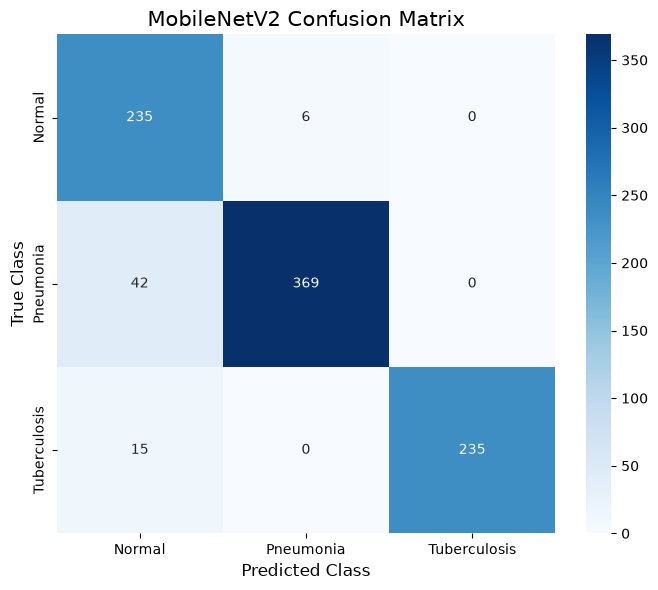

Confusion matrix image saved as:
MobileNetV2_confusion_matrix.png


In [20]:
# Cell 18: MobileNetV2 Confusion Matrix Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True
)

plt.title("MobileNetV2 Confusion Matrix", fontsize=15)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)

plt.tight_layout()

# Save high-resolution image for IEEE paper
plt.savefig(
    "MobileNetV2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix image saved as:")
print("MobileNetV2_confusion_matrix.png")

MOBILENETV2 ROC-AUC ANALYSIS

Per-class ROC-AUC:
Normal         : 0.989981
Pneumonia      : 0.993181
Tuberculosis   : 0.999067

Macro ROC-AUC     : 0.994077
Macro ROC-AUC (%) : 99.41%


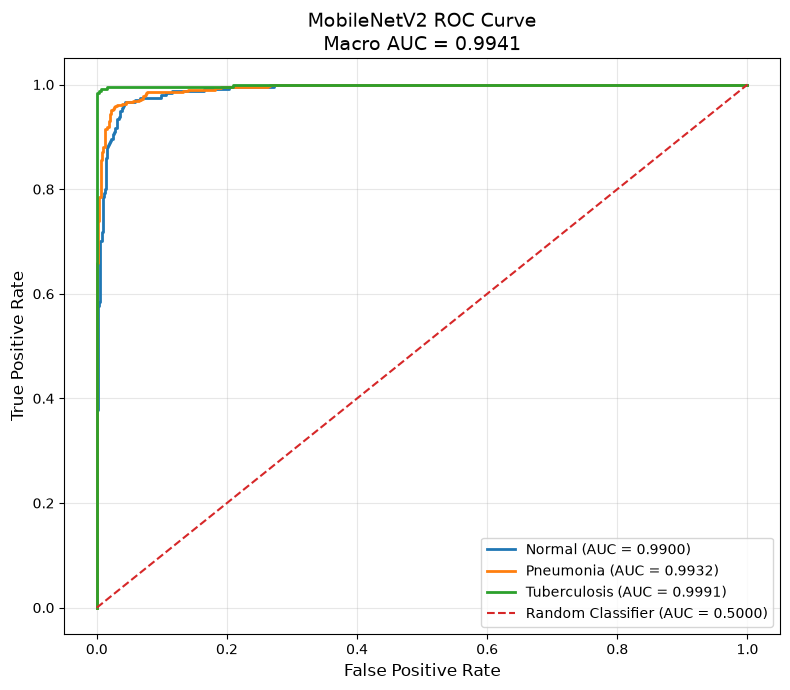


ROC curve image saved as:
MobileNetV2_ROC_Curve.png


In [21]:
# Cell 19: MobileNetV2 ROC Curve and Macro ROC-AUC

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

print("=" * 60)
print("MOBILENETV2 ROC-AUC ANALYSIS")
print("=" * 60)

# Convert true labels to one-hot/binary format
y_true_bin = label_binarize(
    y_true,
    classes=[0, 1, 2]
)

# Calculate ROC-AUC for each class
roc_auc = {}

for i, class_name in enumerate(CLASS_NAMES):
    roc_auc[i] = roc_auc_score(
        y_true_bin[:, i],
        y_pred_proba[:, i]
    )

# Calculate macro ROC-AUC
macro_roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_proba,
    average="macro",
    multi_class="ovr"
)

print("\nPer-class ROC-AUC:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name:<15}: {roc_auc[i]:.6f}")

print(f"\nMacro ROC-AUC     : {macro_roc_auc:.6f}")
print(f"Macro ROC-AUC (%) : {macro_roc_auc * 100:.2f}%")

# ----------------------------------------------------------
# Plot ROC curves
# ----------------------------------------------------------

plt.figure(figsize=(8, 7))

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_proba[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    f"MobileNetV2 ROC Curve\nMacro AUC = {macro_roc_auc:.4f}",
    fontsize=14
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.grid(alpha=0.3)
plt.tight_layout()

# Save high-resolution image for IEEE paper
plt.savefig(
    "MobileNetV2_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nROC curve image saved as:")
print("MobileNetV2_ROC_Curve.png")